# News-Debate Topic Correlation
## Dec 18 Newscasts  →  Dec 19-21 Debates

**Question:** Do the topics jointly covered by RTP and TVI on Dec 18 (a measure of the most important topics on that day) appear in presidential debates held on Dec 19, 20, and 21?

**Methodology** 
1. Preprocess Dec 18 RTP + TVI OCR into per-minute documents
2. TF-IDF + cosine similarity heatmap (RTP minutes × TVI minutes)
3. Keep pairs with similarity ≥ 0.15 (arbitrarily selected)
4. KMeans on the high-similarity documents to label each topic cluster
5. Vectorise Dec 19-21 debate transcripts in the same TF-IDF space
6. Cosine similarity between each debate and each newscast cluster centroid
7. Identify the shared terms that link each debate to each newscast topic

In [1]:
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

BASE       = Path.cwd()
THRESHOLD  = 0.15
N_CLUSTERS = 6

PT_STOP = set([
    'a','ao','aos','aquela','aquelas','aquele','aqueles','aquilo','as',
    'com','como','da','das','de','dela','delas','dele','deles','depois','do',
    'dos','e','ela','elas','ele','eles','em','entre','era','essa','essas',
    'esse','esses','esta','estas','este','estes','eu','foi','foram',
    'isso','isto','lhe','lhes','me','mais','mas','mesmo','meu','meus',
    'minha','minhas','muito','na','nas','nem','no','nos','nossa',
    'nossas','nosso','nossos','num','numa','o','os','ou','para','pela','pelas',
    'pelo','pelos','por','qual','quando','que','se','sem','ser','seu','seus',
    'sua','suas','te','tem','tinha','todo','todos','tu',
    'um','uma','uns','umas','tvi','rtp','telejornal',
])

## 1. Load and Preprocess Dec 18 Newscasts


In [2]:
def strip_html(text):
    return re.sub(r'<[^>]+>', '', text)

def extract_clock_min(ocr_list):
    for d in ocr_list:
        m = re.search(r'(2[0-2]):([0-5]\d)', d['text'])
        if m:
            return int(m.group(1)) * 60 + int(m.group(2))
    return None

def extract_text(ocr_list, min_conf=0.6):
    parts = [strip_html(d['text']) for d in ocr_list if d['conf'] >= min_conf]
    return ' '.join(parts)

def preprocess(df, channel):
    df = df.copy()
    df['channel']   = channel
    df['frame_num'] = df['Frame'].str.extract(r'frame_(\d+)').astype(int)
    df['time_min']  = df['OCR'].apply(extract_clock_min)
    df['text']      = df['OCR'].apply(extract_text)
    return df.sort_values('frame_num').reset_index(drop=True)

def aggregate_text_by_minute(df):
    df = df[df['time_min'].notna()].copy()
    df['minute'] = df['time_min'].astype(int)
    grouped = df.groupby('minute')['text'].apply(lambda x: ' '.join(x)).reset_index()
    grouped.columns = ['minute', 'text']
    return grouped


rtp_raw = pd.read_pickle(BASE / 'Telejornal_RTP_Dec_18_ocr.pkl')
tvi_raw = pd.read_pickle(BASE / 'Telejornal_TVI_Dec_18_ocr.pkl')

rtp_t = preprocess(rtp_raw, 'RTP')
tvi_t = preprocess(tvi_raw, 'TVI')
rtp_t = rtp_t[rtp_t['time_min'].notna()]
tvi_t = tvi_t[tvi_t['time_min'].notna()]

rtp_min = aggregate_text_by_minute(rtp_t)
tvi_min = aggregate_text_by_minute(tvi_t)

overlap = set(rtp_min['minute']) & set(tvi_min['minute'])

print(f"RTP valid frames: {len(rtp_t)}  | "
      f"time: {int(rtp_t.time_min.min()//60):02d}:{int(rtp_t.time_min.min()%60):02d}"
      f" - {int(rtp_t.time_min.max()//60):02d}:{int(rtp_t.time_min.max()%60):02d}")
print(f"TVI valid frames: {len(tvi_t)}  | "
      f"time: {int(tvi_t.time_min.min()//60):02d}:{int(tvi_t.time_min.min()%60):02d}"
      f" - {int(tvi_t.time_min.max()//60):02d}:{int(tvi_t.time_min.max()%60):02d}")
print(f"Overlapping minutes: {len(overlap)}")
print(f"RTP minutes: {sorted(rtp_min.minute.tolist())}")
print(f"TVI minutes: {sorted(tvi_min.minute.tolist())}")

RTP valid frames: 1130  | time: 20:00 - 20:18
TVI valid frames: 3520  | time: 20:00 - 21:38
Overlapping minutes: 19
RTP minutes: [1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218]
TVI minutes: [1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1247, 1248, 1249, 1250, 1265, 1266, 1267, 1268, 1269, 1270, 1271, 1272, 1273, 1274, 1275, 1297, 1298]


## 2. TF-IDF + Cosine Similarity Heatmap (Dec 18)

Fit TF-IDF on the combined Dec 18 minute corpus, then compute an RTP × TVI cosine similarity matrix.  High-similarity cells indicate the two channels covered the same story at those times.

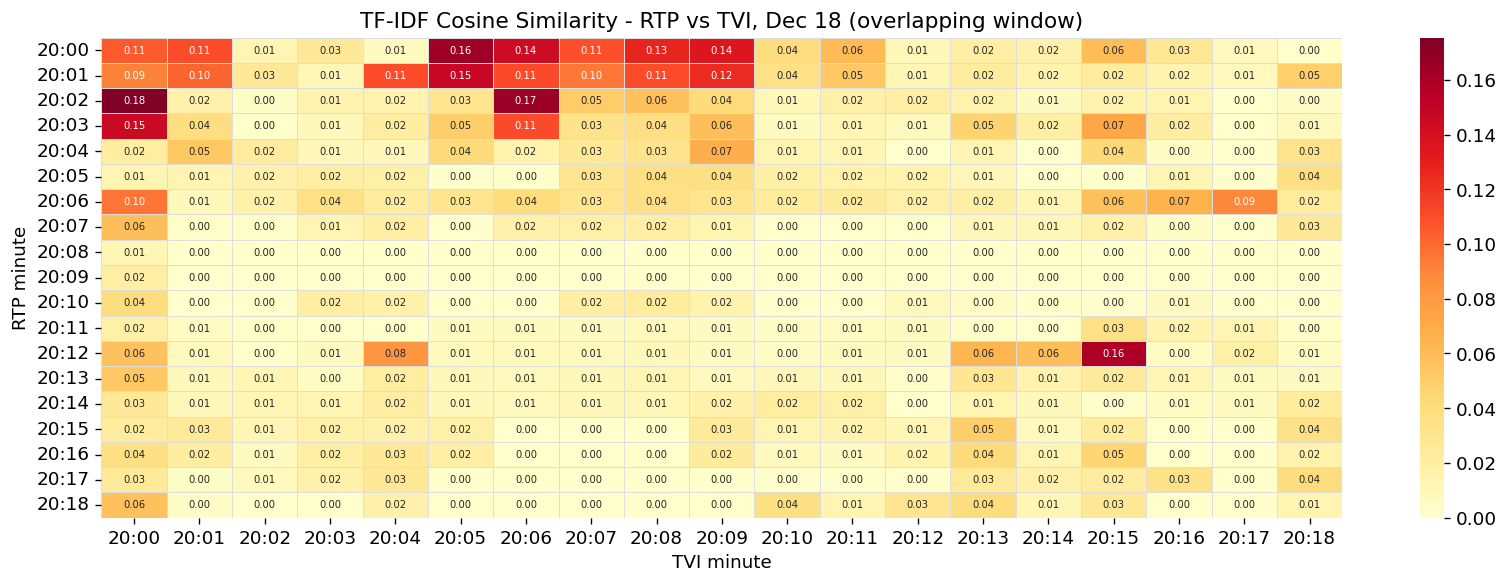

Vocabulary size: 1461
Max similarity:  0.232
Pairs >= 0.15:  10


In [3]:
rtp_docs = list(rtp_min['text'])
tvi_docs = list(tvi_min['text'])
all_docs = rtp_docs + tvi_docs

vectorizer = TfidfVectorizer(
    stop_words    = list(PT_STOP),
    min_df        = 2,
    max_df        = 0.85,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    token_pattern = r'[A-Za-z\u00e0-\u00fc\u00c0-\u00dc]{3,}',
)
tfidf_all = vectorizer.fit_transform(all_docs)
feature_names = vectorizer.get_feature_names_out()

n_rtp     = len(rtp_docs)
tfidf_rtp = tfidf_all[:n_rtp]
tfidf_tvi = tfidf_all[n_rtp:]

sim_matrix = cosine_similarity(tfidf_rtp, tfidf_tvi)

sim_df = pd.DataFrame(
    sim_matrix,
    index   = [f"{int(m//60):02d}:{int(m%60):02d}" for m in rtp_min['minute']],
    columns = [f"{int(m//60):02d}:{int(m%60):02d}" for m in tvi_min['minute']],
)

overlap_cols = [f"{int(m//60):02d}:{int(m%60):02d}" for m in sorted(overlap)]
sim_overlap  = sim_df[overlap_cols]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    sim_overlap, ax=ax, cmap='YlOrRd',
    vmin=0, vmax=sim_overlap.values.max(),
    linewidths=0.3, linecolor='#ddd',
    annot=True, fmt='.2f', annot_kws={'size': 6},
)
ax.set_title('TF-IDF Cosine Similarity - RTP vs TVI, Dec 18 (overlapping window)', fontsize=13)
ax.set_xlabel('TVI minute')
ax.set_ylabel('RTP minute')
plt.tight_layout()
plt.savefig(BASE / 'fig_similarity_heatmap_dec18.png', bbox_inches='tight')
plt.show()

print(f"Vocabulary size: {len(feature_names)}")
print(f"Max similarity:  {sim_matrix.max():.3f}")
print(f"Pairs >= {THRESHOLD}:  {int((sim_matrix >= THRESHOLD).sum())}")

## 3. Shared Topics: High-Similarity Pairs + KMeans Clusters

Keep all RTP-TVI minute pairs with cosine similarity >= 0.15. Run KMeans on the involved documents (L2-normalised) to identify the main topics both channels covered jointly on Dec 18.


In [4]:
# Collect high-similarity pairs
high_sim_pairs = []
for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        if sim_matrix[i, j] >= THRESHOLD:
            high_sim_pairs.append({
                'rtp_idx':    i,
                'tvi_idx':    j,
                'rtp_min':    rtp_min.iloc[i]['minute'],
                'tvi_min':    tvi_min.iloc[j]['minute'],
                'similarity': sim_matrix[i, j],
            })

pairs_df = (pd.DataFrame(high_sim_pairs)
              .sort_values('similarity', ascending=False)
              .reset_index(drop=True))
pairs_df['rtp_lbl'] = pairs_df['rtp_min'].apply(lambda m: f"{int(m//60):02d}:{int(m%60):02d}")
pairs_df['tvi_lbl'] = pairs_df['tvi_min'].apply(lambda m: f"{int(m//60):02d}:{int(m%60):02d}")

print(f"Pairs with similarity >= {THRESHOLD}: {len(pairs_df)}")

# KMeans on documents involved in high-similarity pairs
unique_rtp_idx = sorted(pairs_df['rtp_idx'].unique())
unique_tvi_idx = sorted(pairs_df['tvi_idx'].unique())
involved_idx   = unique_rtp_idx + [n_rtp + j for j in unique_tvi_idx]

X_high      = tfidf_all[involved_idx]
X_high_norm = normalize(X_high, norm='l2')

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_high_norm)
labels = kmeans.labels_

# Top terms per cluster
cluster_top_terms = []
print(f"\n=== Shared Newscast Topic Clusters (Dec 18, threshold={THRESHOLD}) ===")
for c in range(N_CLUSTERS):
    centroid = kmeans.cluster_centers_[c]
    top_i    = centroid.argsort()[::-1][:8]
    words    = [feature_names[k] for k in top_i if centroid[k] > 0]
    cluster_top_terms.append(words)
    print(f"  Cluster {c+1}: {' | '.join(words)}")

# Map RTP documents to their cluster label
rtp_cluster_map = {rtp_i: int(labels[pos]) for pos, rtp_i in enumerate(unique_rtp_idx)}

def shared_top_terms(rtp_vec, tvi_vec, n=6):
    arr_r = np.array(rtp_vec.todense()).flatten()
    arr_t = np.array(tvi_vec.todense()).flatten()
    shared = np.minimum(arr_r, arr_t)
    idx = shared.argsort()[::-1][:n]
    return [feature_names[k] for k in idx if shared[k] > 0]



Pairs with similarity >= 0.15: 10

=== Shared Newscast Topic Clusters (Dec 18, threshold=0.15) ===
  Cluster 1: party the | the party | party | agricultores | nível | the | diz | caminho
  Cluster 2: spinumviva | spinumviva arquivado | arquivado | caso spinumviva | caso | pgr | causa | arquivamento
  Cluster 3: bruxelas bélgica | bélgica dia | ucrânia direto | debatem financiamento | debatem | dia bruxelas | dia | líderes
  Cluster 4: ativos | ativos russos | russos | mil milhões | mobilização | russos qui | mobilização ativos | contra mobilização
  Cluster 5: descontentes | agricultores descontentes | agricultores | descontentes agricultores | bruxelas agricultores | bruxelas | parlamento europeu | parlamento
  Cluster 6: ventura | lei | tribunal | responsabilidade | qui | nacionalidade | lei nacionalidade | nacionalidade chumbada


## 4. t-SNE Projection of Newscast Clusters



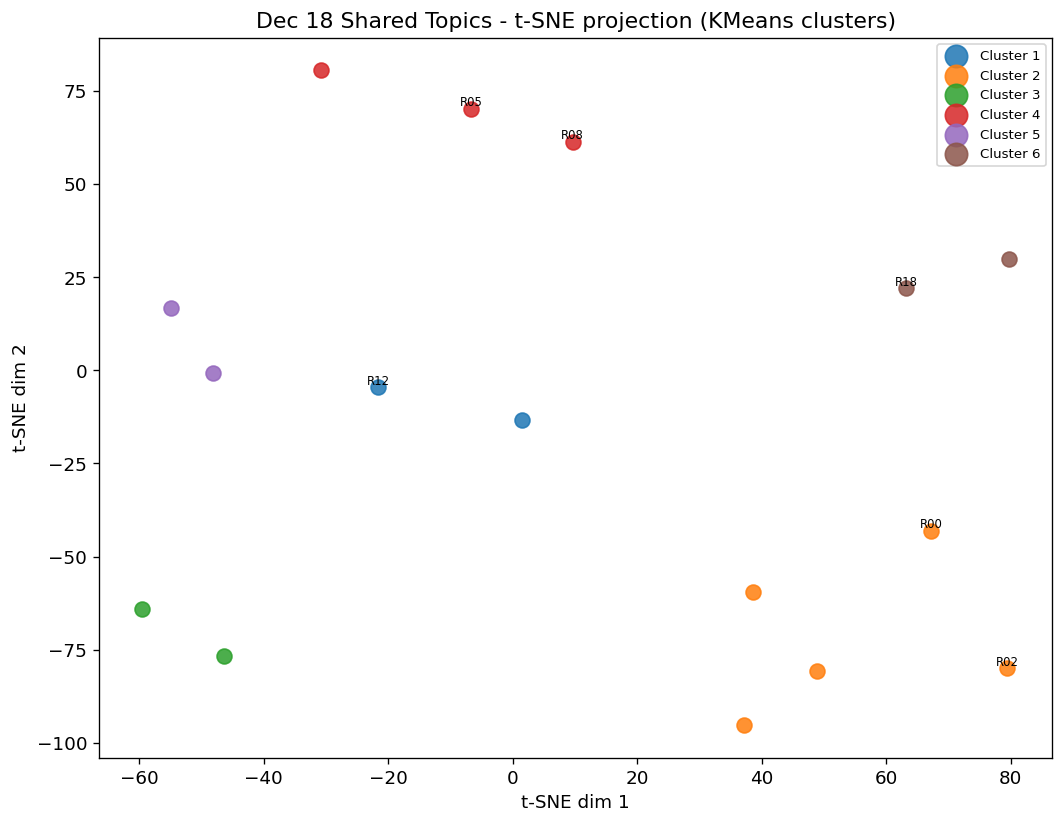

In [5]:
cluster_colors = plt.cm.tab10.colors

tsne = TSNE(n_components=2, perplexity=5, random_state=42, max_iter=1000)
X_2d = tsne.fit_transform(X_high_norm.toarray())

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(N_CLUSTERS):
    mask = labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=cluster_colors[c], label=f'Cluster {c+1}', s=80, alpha=0.85)

for pos, rtp_i in enumerate(unique_rtp_idx):
    lbl = f"R{int(rtp_min.iloc[rtp_i]['minute'] % 60):02d}"
    ax.annotate(lbl, (X_2d[pos, 0], X_2d[pos, 1]), fontsize=7, ha='center', va='bottom')

ax.set_title('Dec 18 Shared Topics - t-SNE projection (KMeans clusters)')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(fontsize=8, markerscale=1.5)
plt.tight_layout()
plt.savefig(BASE / 'fig_dec18_tsne_clusters.png', bbox_inches='tight')
plt.show()

## 5. Load Dec 19-21 Debate Transcripts

Load the pre-built debate summary dataframe and select the four debates held on Dec 19, 20, and 21 — the days immediately following the Dec 18 newscast.

In [8]:
debate_df = pd.read_pickle(BASE / 'debate_topic_summary_timeline.pkl')
debate_df = debate_df.sort_values('debate_date').reset_index(drop=True)

TARGET_DATES = {
    pd.Timestamp('2025-12-19').date(),
    pd.Timestamp('2025-12-20').date(),
    pd.Timestamp('2025-12-21').date(),
}
target_df = (debate_df[debate_df['debate_date'].dt.date.isin(TARGET_DATES)]
               .reset_index(drop=True))

## 6. Vectorise Debates in the Newscast Feature Space

Apply the Dec 18 newscast vectorizer to the debate transcripts. This projects each debate into the newcast vocabulary (only the shared topics between newcast on that day), so cosine similarity directly measures how much of the newscast language each debate used.

In [9]:
# Project debate transcripts into the newscast feature space
tfidf_target = vectorizer.transform(target_df['full_transcript'].astype(str))

# Similarity of each target debate vs each newscast cluster centroid
cluster_centers_sp = sp.csr_matrix(kmeans.cluster_centers_)
sim_dc = cosine_similarity(tfidf_target, cluster_centers_sp)  # shape: (n_debates, N_CLUSTERS)

target_df = target_df.copy()
for c in range(N_CLUSTERS):
    target_df[f'sim_nc{c+1}'] = sim_dc[:, c]
target_df['best_newscast_cluster'] = sim_dc.argmax(axis=1) + 1
target_df['best_cluster_sim']      = sim_dc.max(axis=1)

print("Debate similarity to each Dec 18 newscast cluster:")
print()
for i, (_, row) in enumerate(target_df.iterrows()):
    best_c = int(sim_dc[i].argmax())
    print(f"[{row['debate_date'].date()}]  {row['debate_name']}")
    print(f"  Best newscast cluster : C{best_c+1} (sim={sim_dc[i, best_c]:.4f})")
    print(f"  Cluster terms         : {' | '.join(cluster_top_terms[best_c][:5])}")
    print(f"  All cluster sims      : ", end='')
    print('  '.join([f"C{c+1}={sim_dc[i,c]:.3f}" for c in range(N_CLUSTERS)]))
    print()

Debate similarity to each Dec 18 newscast cluster:

[2025-12-19]  Cotrim_Figueiredo_vs_Ventura_December_19
  Best newscast cluster : C5 (sim=0.2164)
  Cluster terms         : descontentes | agricultores descontentes | agricultores | descontentes agricultores | bruxelas agricultores
  All cluster sims      : C1=0.197  C2=0.182  C3=0.063  C4=0.055  C5=0.216  C6=0.148

[2025-12-19]  Seguro_vs_Filipe_December_19
  Best newscast cluster : C2 (sim=0.2030)
  Cluster terms         : spinumviva | spinumviva arquivado | arquivado | caso spinumviva | caso
  All cluster sims      : C1=0.164  C2=0.203  C3=0.047  C4=0.057  C5=0.139  C6=0.078

[2025-12-20]  Martins_vs_Pinto_December_20
  Best newscast cluster : C2 (sim=0.1821)
  Cluster terms         : spinumviva | spinumviva arquivado | arquivado | caso spinumviva | caso
  All cluster sims      : C1=0.181  C2=0.182  C3=0.041  C4=0.060  C5=0.152  C6=0.085

[2025-12-21]  Marques_Mendes_vs_Gouveia_Melo_December_21
  Best newscast cluster : C2 (sim=0.21

## 7. Heatmap: Debates vs Newscast Clusters

Each row is one of the four target debates; each column is a Dec 18 shared-topic cluster. The cell value is the cosine similarity between the debate transcript and the cluster centroid in the newscast vocabulary space.

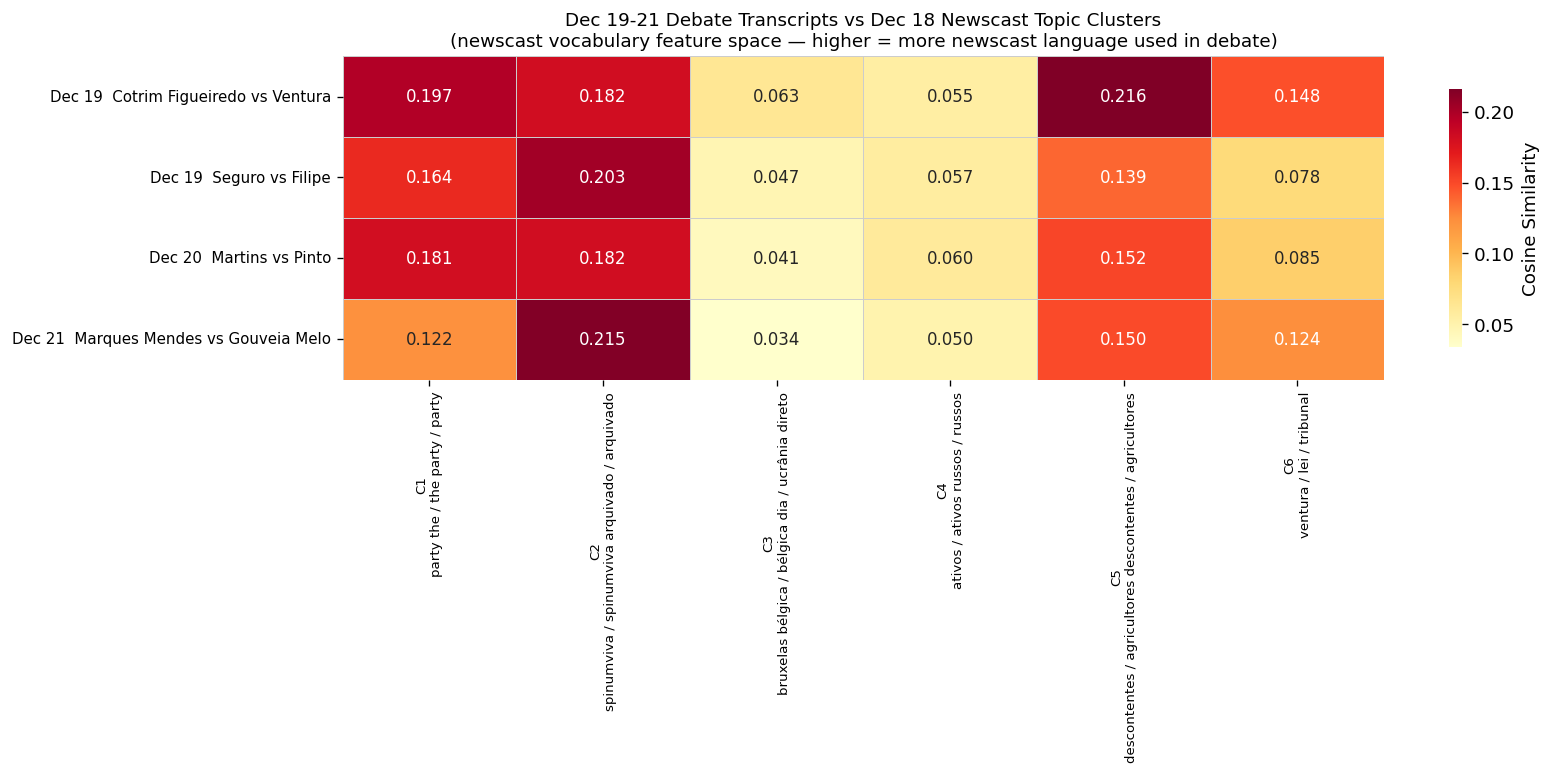

In [10]:
col_labels = []
for c in range(N_CLUSTERS):
    top3 = ' / '.join(cluster_top_terms[c][:3])
    col_labels.append(f"C{c+1}\n{top3}")

def short_debate_name(row):
    parts = row['debate_name'].split('_vs_')
    a = parts[0].replace('_', ' ')
    b = '_'.join(parts[1].split('_')[:-2]).replace('_', ' ') if len(parts) > 1 else ''
    return f"{row['debate_date'].strftime('%b %d')}  {a} vs {b}"

heatmap_data = pd.DataFrame(
    sim_dc,
    index   = [short_debate_name(r) for _, r in target_df.iterrows()],
    columns = col_labels,
)

fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(
    heatmap_data,
    ax         = ax,
    cmap       = 'YlOrRd',
    annot      = True,
    fmt        = '.3f',
    annot_kws  = {'size': 10},
    linewidths = 0.5,
    linecolor  = '#ccc',
    cbar_kws   = {'label': 'Cosine Similarity', 'shrink': 0.8},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Dec 19-21 Debate Transcripts vs Dec 18 Newscast Topic Clusters\n'
             '(newscast vocabulary feature space — higher = more newscast language used in debate)',
             fontsize=11)
plt.tight_layout()
plt.savefig(BASE / 'fig_debate_vs_newscast_heatmap.png', bbox_inches='tight')
plt.show()